In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score

In [3]:
X_train = np.load("C:/DS_mainproject/portfolio_prjct/PORTFOLIO_PROJECT/data/processed/X_train.npy")
y_train = np.load("C:/DS_mainproject/portfolio_prjct/PORTFOLIO_PROJECT/data/processed/y_train.npy")
X_test = np.load("C:/DS_mainproject/portfolio_prjct/PORTFOLIO_PROJECT/data/processed/X_test.npy")
y_test = np.load("C:/DS_mainproject/portfolio_prjct/PORTFOLIO_PROJECT/data/processed/y_test.npy")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (30976, 30, 15)
y_train shape: (30976,)


In [4]:
lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1, activation='sigmoid'))  # Binary classification

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

lstm_model.summary() 

C:\DS_mainproject\portfolio_prjct\portfolio_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          20,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# gru_model = Sequential()
# gru_model.add(GRU(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
# gru_model.add(Dropout(0.2))
# gru_model.add(Dense(1, activation='sigmoid'))

# gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# gru_model.summary()

In [6]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss does not improve
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# --------- Train LSTM ---------
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5749 - loss: 0.6717 - val_accuracy: 0.6298 - val_loss: 0.6407
Epoch 2/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6349 - loss: 0.6396 - val_accuracy: 0.6385 - val_loss: 0.6391
Epoch 3/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6386 - loss: 0.6370 - val_accuracy: 0.6370 - val_loss: 0.6388
Epoch 4/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6407 - loss: 0.6351 - val_accuracy: 0.6422 - val_loss: 0.6344
Epoch 5/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6441 - loss: 0.6330 - val_accuracy: 0.6414 - val_loss: 0.6333
Epoch 6/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6450 - loss: 0.6306 - val_accuracy: 0.6404 - val_loss: 0.6320
Epoch 7/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6459 - loss: 0.6306 - val_accuracy: 0.6369 - val_loss: 0.6318
Epoch 8/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6462 - loss: 0.6286 - val_acc

In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Get predicted probabilities
y_pred_prob = lstm_model.predict(X_test)

# Convert probabilities to 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int)

# Flatten arrays (important)
y_test_flat = y_test.reshape(-1)
y_pred_flat = y_pred.reshape(-1)
accuracy = accuracy_score(y_test_flat, y_pred_flat)
precision = precision_score(y_test_flat, y_pred_flat)
recall = recall_score(y_test_flat, y_pred_flat)
f1 = f1_score(y_test_flat, y_pred_flat)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy : 0.6744576446280992
Precision: 0.7043968432919955
Recall   : 0.7208121827411168
F1 Score : 0.7125099783327632


In [8]:
lstm_model.evaluate(X_test,y_test)

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6745 - loss: 0.6020


[0.601955771446228, 0.6744576692581177]

In [9]:
cm = confusion_matrix(y_test_flat, y_pred_flat)
print(cm)

[[2099 1311]
 [1210 3124]]


In [10]:
# Save the entire model (architecture + weights + optimizer state)
lstm_model.save('C:/DS_mainproject/portfolio_prjct/PORTFOLIO_PROJECT/models/lstm_model.h5')

# Or save in the newer Keras format
lstm_model.save('C:/DS_mainproject/portfolio_prjct/PORTFOLIO_PROJECT/models/lstm_model.keras')

print("Model saved successfully!")

Model saved successfully!


In [11]:
# Create models directory if it doesn't exist
import os
models_dir = 'C:/DS_mainproject/portfolio_prjct/PORTFOLIO_PROJECT/models'
os.makedirs(models_dir, exist_ok=True)

# --------- Build GRU Model (same structure as LSTM) ---------
gru_model = Sequential()
gru_model.add(GRU(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(1, activation='sigmoid'))

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n" + "="*50)
print("GRU MODEL SUMMARY")
print("="*50)
gru_model.summary()


GRU MODEL SUMMARY


C:\DS_mainproject\portfolio_prjct\portfolio_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 64)                  │          15,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,617 (61.00 KB)

 Trainable params: 15,617 (61.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train GRU
print("\n" + "="*50)
print("TRAINING GRU MODEL")
print("="*50)
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Save GRU model
gru_model.save(os.path.join(models_dir, 'gru_model.keras'))
print("\n✅ GRU model saved successfully!")


TRAINING GRU MODEL
Epoch 1/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6077 - loss: 0.6579 - val_accuracy: 0.6364 - val_loss: 0.6405
Epoch 2/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6421 - loss: 0.6365 - val_accuracy: 0.6440 - val_loss: 0.6345
Epoch 3/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6436 - loss: 0.6338 - val_accuracy: 0.6423 - val_loss: 0.6330
Epoch 4/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6441 - loss: 0.6308 - val_accuracy: 0.6423 - val_loss: 0.6311
Epoch 5/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6468 - loss: 0.6277 - val_accuracy: 0.6498 - val_loss: 0.6246
Epoch 6/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6536 - loss: 0.6226 - val_accuracy: 0.6574 - val_loss: 0.6227
Epoch 7/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6537 - loss: 0.6210 - val_accuracy: 0.6567 - val_loss: 0.6202
Epoch 8/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6559 -

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# Function to evaluate model
def evaluate_model(model, X_test, y_test, model_name):
    # Get predictions
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    # Flatten arrays
    y_test_flat = y_test.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_flat, y_pred_flat)
    precision = precision_score(y_test_flat, y_pred_flat)
    recall = recall_score(y_test_flat, y_pred_flat)
    f1 = f1_score(y_test_flat, y_pred_flat)
    cm = confusion_matrix(y_test_flat, y_pred_flat)
    
    # Print results
    print(f"\n{'='*50}")
    print(f"{model_name} EVALUATION RESULTS")
    print(f"{'='*50}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Confusion Matrix': cm
    }

# Evaluate both models
lstm_results = evaluate_model(lstm_model, X_test, y_test, "LSTM")
gru_results = evaluate_model(gru_model, X_test, y_test, "GRU")

242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

LSTM EVALUATION RESULTS
Accuracy : 0.6745
Precision: 0.7044
Recall   : 0.7208
F1 Score : 0.7125

Confusion Matrix:
[[2099 1311]
 [1210 3124]]
242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

GRU EVALUATION RESULTS
Accuracy : 0.6810
Precision: 0.7052
Recall   : 0.7390
F1 Score : 0.7217

Confusion Matrix:
[[2071 1339]
 [1131 3203]]


In [14]:
# Create comparison dataframe
comparison_df = pd.DataFrame([
    lstm_results,
    gru_results
])

# Drop confusion matrix from display (too large)
display_df = comparison_df.drop('Confusion Matrix', axis=1)
print("\n" + "="*50)
print("LSTM vs GRU COMPARISON")
print("="*50)
print(display_df.to_string(index=False))

# Find the better model
better_model = display_df.loc[display_df['F1 Score'].idxmax(), 'Model']
better_f1 = display_df['F1 Score'].max()
print(f"\n✅ Better model: {better_model} (F1 Score: {better_f1:.4f})")


LSTM vs GRU COMPARISON
Model  Accuracy  Precision   Recall  F1 Score
 LSTM  0.674458   0.704397 0.720812  0.712510
  GRU  0.681043   0.705196 0.739040  0.721721

✅ Better model: GRU (F1 Score: 0.7217)


In [15]:
# Save the best performing model
if lstm_results['F1 Score'] > gru_results['F1 Score']:
    best_model = lstm_model
    best_model_name = "LSTM"
    best_model.save(os.path.join(models_dir, 'best_model_lstm.keras'))
else:
    best_model = gru_model
    best_model_name = "GRU"
    best_model.save(os.path.join(models_dir, 'best_model_gru.keras'))

print(f"\n✅ Best model ({best_model_name}) saved as 'best_model.keras'")

# Also save comparison results to CSV
comparison_df.to_csv(os.path.join(models_dir, 'model_comparison.csv'), index=False)
print("✅ Model comparison saved to 'model_comparison.csv'")


✅ Best model (GRU) saved as 'best_model.keras'
✅ Model comparison saved to 'model_comparison.csv'


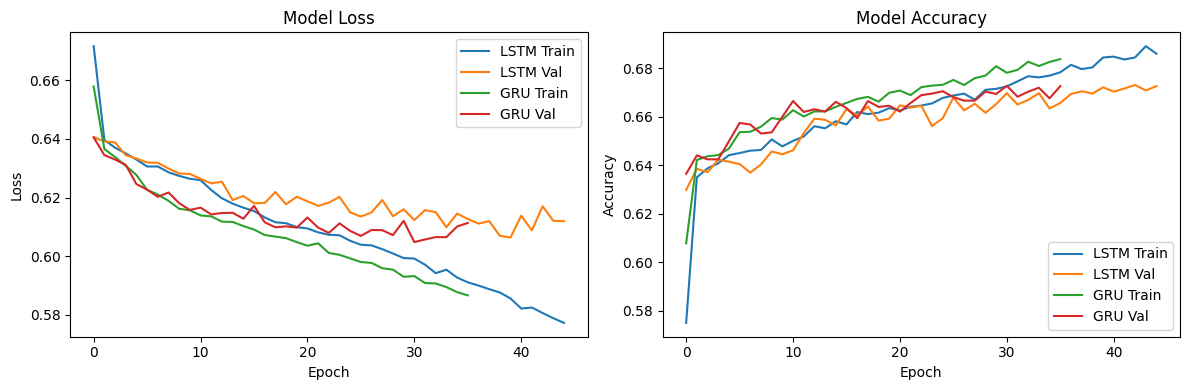

✅ Training history saved


In [16]:
# ============================================
# SAVE TRAINING HISTORY FOR ANALYSIS
# ============================================

import pickle
import matplotlib.pyplot as plt

# Save training histories
history_path = os.path.join(models_dir, 'training_history.pkl')
with open(history_path, 'wb') as f:
    pickle.dump({
        'lstm': history_lstm.history,
        'gru': history_gru.history
    }, f)

# Plot training curves for comparison
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_lstm.history['loss'], label='LSTM Train')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val')
plt.plot(history_gru.history['loss'], label='GRU Train')
plt.plot(history_gru.history['val_loss'], label='GRU Val')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_lstm.history['accuracy'], label='LSTM Train')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val')
plt.plot(history_gru.history['accuracy'], label='GRU Train')
plt.plot(history_gru.history['val_accuracy'], label='GRU Val')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'training_curves.png'))
plt.show()

print("✅ Training history saved")

In [17]:
total_predictions = len(y_test_flat)
correct_predictions = np.sum(y_test_flat == y_pred_flat)
wrong_predictions = total_predictions - correct_predictions

print(f"\n📈 TOTAL PREDICTIONS: {total_predictions}")
print(f"✅ CORRECT predictions: {correct_predictions} ({correct_predictions/total_predictions*100:.2f}%)")
print(f"❌ WRONG predictions: {wrong_predictions} ({wrong_predictions/total_predictions*100:.2f}%)")



📈 TOTAL PREDICTIONS: 7744
✅ CORRECT predictions: 5223 (67.45%)
❌ WRONG predictions: 2521 (32.55%)
